<a id='I'></a>
# MCDI503 — Exploración Inteligente para la Ciencia de Datos
## Avance Sumativo — Fases 2 y 3
### I. Encabezado e identificación del notebook

| Campo | Detalle |
|---|---|
| **Curso** | MCDI503 — Exploración Inteligente para la Ciencia de Datos |
| **Evaluación** | Sumativa 2 — Fases 2 y 3 |
| **Integrantes** | Marcelo Corro · Carolina Cortés · Pedro Espinoza · Juan Valdebenito |
| **Dataset** | Titanic (seaborn built-in · 891 obs × 15 variables) |
| **Docente** | Sergio Paraíso |
| **Fecha** | Septiembre 2026 |
| **Repositorio** | https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi503 |

**Propósito general del Notebook:**
Documentar de forma reproducible el proceso técnico de preparación analítica del dataset Titanic: diagnóstico de calidad, limpieza, integración con fuente auxiliar, transformaciones de variables y análisis exploratorio univariado y bivariado completo, con identificación de patrones, anomalías y hallazgos iniciales defendibles.

**Pertinencia del dataset:** se seleccionó Titanic por ser el dataset recomendado por la asignatura y porque permite recorrer completamente las Fases 2 y 3: presenta valores faltantes de distinta magnitud (`deck`, `age`, `embarked`), duplicados, columnas redundantes, variables numéricas asimétricas con outliers y variables categóricas que admiten integración con una tabla auxiliar (puertos de embarque).

**Alcance:** el trabajo es exclusivamente exploratorio y descriptivo. No se aplican pruebas de hipótesis ni modelos predictivos; las asociaciones reportadas no implican causalidad.

---
## Índice

- [I. Encabezado e identificación](#I)
- [II. Carga del dataset y descripción inicial](#II)
- [III. Revisión del contenido del dataset](#III)
- [IV. Diagnóstico de calidad de datos](#IV)
- [V. Limpieza, validación e integración](#V)
- [VI. Transformaciones aplicadas y preparación del dataset](#VI)
- [VII. Análisis univariado](#VII)
- [VIII. Análisis bivariado](#VIII)
- [IX. Patrones, anomalías y hallazgos iniciales](#IX)
- [X. Supuestos, Limitaciones y Estado final del dataset](#X)
- [XI. Cierre del avance](#XI)
- [XII. Bibliografía](#XII)

[8] Wikipedia. (2026). *Cherburgo*, *Cobh* y *Southampton* [Artículos de enciclopedia en línea]. Recuperado de https://es.wikipedia.org/wiki/Cherburgo, https://es.wikipedia.org/wiki/Cobh y https://es.wikipedia.org/wiki/Southampton


<a id='II'></a>
## II. Carga del dataset y descripción inicial

Se importan las librerías necesarias y se carga el dataset desde `seaborn`, garantizando que el análisis sea reproducible sin archivos locales. Se fijan semillas y parámetros gráficos globales.

In [1]:
import warnings
# Se silencian solo avisos de deprecación de librerías (no afectan los resultados)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# Versiones utilizadas (reproducibilidad)
print(f'Versiones -> pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

# ── Parámetros globales ──────────────────────────────────────────────────
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (9, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = {'survived': '#2ecc71', 'not_survived': '#e74c3c'}
FIGDIR  = 'reports/figures'
import os; os.makedirs(FIGDIR, exist_ok=True)

# ── Carga ────────────────────────────────────────────────────────────────
df_raw = sns.load_dataset('titanic')
print(f'Dimensiones originales: {df_raw.shape}')
df_raw.head()

Versiones -> pandas 2.2.3 | numpy 2.2.6 | seaborn 0.13.2
Dimensiones originales: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Observación inicial:** El dataset tiene 891 filas y 15 columnas. Se verifica que la carga fue exitosa y se preserva `df_raw` como copia inmutable de referencia.

In [2]:
print('Columnas:', df_raw.columns.tolist())
print('\nTipos de datos:')
print(df_raw.dtypes)

Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Tipos de datos:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


<a id='III'></a>
## III. Revisión del contenido del dataset

Se inspecciona el contenido del dataset: tipos de variables, nombres de campos, cardinalidades y observaciones generales sobre la estructura.

In [3]:
# Resumen estructural
summary = pd.DataFrame({
    'dtype':      df_raw.dtypes,
    'n_nulos':    df_raw.isnull().sum(),
    'pct_nulos':  (df_raw.isnull().mean()*100).round(2),
    'n_unicos':   df_raw.nunique(),
    'ejemplo':    df_raw.iloc[0]
})
print(summary.to_string())

                dtype  n_nulos  pct_nulos  n_unicos      ejemplo
survived        int64        0       0.00         2            0
pclass          int64        0       0.00         3            3
sex            object        0       0.00         2         male
age           float64      177      19.87        88         22.0
sibsp           int64        0       0.00         7            1
parch           int64        0       0.00         7            0
fare          float64        0       0.00       248         7.25
embarked       object        2       0.22         3            S
class        category        0       0.00         3        Third
who            object        0       0.00         3          man
adult_male       bool        0       0.00         2         True
deck         category      688      77.22         7          NaN
embark_town    object        2       0.22         3  Southampton
alive          object        0       0.00         2           no
alone            bool    

**Observaciones sobre la estructura:**

| Variable | Tipo | Rol analítico |
|---|---|---|
| `survived` | int64 | Variable objetivo binaria (0=no, 1=sí) |
| `pclass` | int64 | Clase de viaje (1ª, 2ª, 3ª) — proxy socioeconómico |
| `sex` | object | Sexo del pasajero |
| `age` | float64 | Edad — **177 valores faltantes (19.9%)** |
| `sibsp` | int64 | N.º de hermanos/cónyuge a bordo |
| `parch` | int64 | N.º de padres/hijos a bordo |
| `fare` | float64 | Tarifa pagada — distribución muy asimétrica |
| `embarked` | object | Puerto de embarque (C/Q/S) — **2 faltantes** |
| `class` | category | Duplicado textual de `pclass` |
| `who` | object | Categoría derivada de `sex`+`age` |
| `adult_male` | bool | Derivada de `sex`+`age` |
| `deck` | category | Cubierta — **688 faltantes (77.2%)** |
| `embark_town` | object | Duplicado textual de `embarked` |
| `alive` | object | Duplicado textual de `survived` |
| `alone` | bool | Derivada de `sibsp`+`parch` |


In [4]:
# Variables con mayor información para el análisis
for col in ['survived','pclass','sex','age','fare','embarked','sibsp','parch']:
    print(f'{col:12s}: {df_raw[col].value_counts(dropna=False).to_dict()}')

survived    : {0: 549, 1: 342}
pclass      : {3: 491, 1: 216, 2: 184}
sex         : {'male': 577, 'female': 314}
age         : {nan: 177, 24.0: 30, 22.0: 27, 18.0: 26, 28.0: 25, 30.0: 25, 19.0: 25, 21.0: 24, 25.0: 23, 36.0: 22, 29.0: 20, 32.0: 18, 26.0: 18, 35.0: 18, 27.0: 18, 31.0: 17, 16.0: 17, 23.0: 15, 20.0: 15, 34.0: 15, 33.0: 15, 39.0: 14, 42.0: 13, 17.0: 13, 40.0: 13, 45.0: 12, 38.0: 11, 2.0: 10, 50.0: 10, 4.0: 10, 48.0: 9, 47.0: 9, 44.0: 9, 54.0: 8, 9.0: 8, 51.0: 7, 1.0: 7, 37.0: 6, 14.0: 6, 52.0: 6, 41.0: 6, 49.0: 6, 3.0: 6, 58.0: 5, 15.0: 5, 43.0: 5, 5.0: 4, 8.0: 4, 11.0: 4, 56.0: 4, 60.0: 4, 62.0: 4, 61.0: 3, 6.0: 3, 46.0: 3, 65.0: 3, 7.0: 3, 13.0: 2, 55.0: 2, 70.0: 2, 57.0: 2, 30.5: 2, 32.5: 2, 71.0: 2, 40.5: 2, 59.0: 2, 0.83: 2, 28.5: 2, 10.0: 2, 0.75: 2, 64.0: 2, 63.0: 2, 45.5: 2, 66.0: 1, 55.5: 1, 70.5: 1, 12.0: 1, 14.5: 1, 36.5: 1, 20.5: 1, 0.92: 1, 23.5: 1, 53.0: 1, 80.0: 1, 24.5: 1, 0.67: 1, 0.42: 1, 34.5: 1, 74.0: 1}
fare        : {8.05: 43, 13.0: 42, 7.8958: 38, 7.7

<a id='IV'></a>
## IV. Diagnóstico de calidad de datos

Se realiza un diagnóstico sistemático de valores faltantes, duplicados e inconsistencias, priorizando variables según su impacto analítico.

=== VALORES FALTANTES ===
             n_faltantes  pct_faltantes
deck                 688          77.22
age                  177          19.87
embarked               2           0.22
embark_town            2           0.22


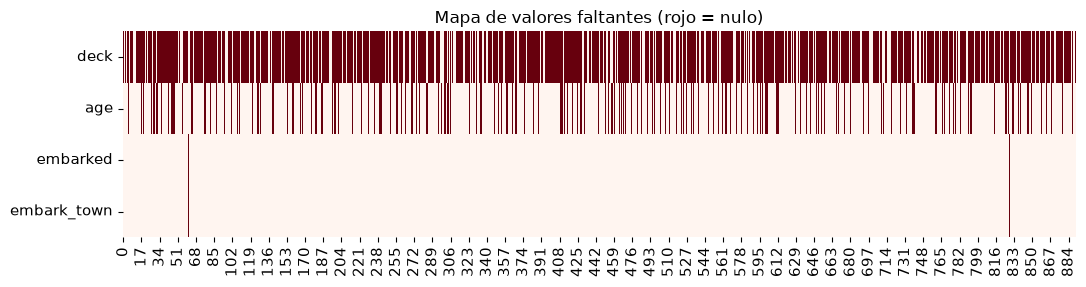

In [5]:
# ── 1. Valores faltantes ────────────────────────────────────────────────
faltantes = pd.DataFrame({
    'n_faltantes': df_raw.isnull().sum(),
    'pct_faltantes': (df_raw.isnull().mean()*100).round(2)
}).sort_values('pct_faltantes', ascending=False)
faltantes = faltantes[faltantes['n_faltantes'] > 0]
print('=== VALORES FALTANTES ===')
print(faltantes.to_string())

# Heatmap de faltantes
fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(df_raw[faltantes.index].isnull().T,
            cbar=False, cmap='Reds', ax=ax, yticklabels=True)
ax.set_title('Mapa de valores faltantes (rojo = nulo)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/f23_heatmap_faltantes.png', bbox_inches='tight')
plt.show()

In [6]:
# ── 1b. Patrón de los faltantes de age (¿MCAR o MAR?) ─────────────────
# Si el porcentaje de faltantes varía según otras variables observadas,
# los faltantes no son completamente aleatorios (MCAR) y es razonable
# imputar condicionando en esas variables (supuesto MAR).
for col in ['pclass', 'sex', 'embarked', 'survived']:
    pct = df_raw['age'].isnull().groupby(df_raw[col]).mean().mul(100).round(1)
    print(f'% de age faltante según {col}: {pct.to_dict()}')

% de age faltante según pclass: {1: 13.9, 2: 6.0, 3: 27.7}
% de age faltante según sex: {'female': 16.9, 'male': 21.5}
% de age faltante según embarked: {'C': 22.6, 'Q': 63.6, 'S': 14.0}
% de age faltante según survived: {0: 22.8, 1: 15.2}


**Lectura:** el porcentaje de `age` faltante no es homogéneo: alcanza **27,7%** en Tercera Clase frente a **13,9%** en Primera y **6,0%** en Segunda, y llega a **63,6%** entre los embarcados en Queenstown. También es mayor entre quienes no sobrevivieron (22,8% vs 15,2%). Por lo tanto, los faltantes **no son completamente aleatorios (MCAR)**: dependen de variables observadas, lo que respalda imputar `age` condicionando en `pclass` y `sex` (supuesto MAR) en lugar de usar una mediana global. Como no sobrevivientes y pasajeros de 3ª clase están sobrerrepresentados entre los faltantes, la imputación puede influir en las comparaciones de edad del análisis bivariado.

In [7]:
# ── 2. Duplicados ───────────────────────────────────────────────────────
n_dup = df_raw.duplicated().sum()
print(f'Filas duplicadas exactas: {n_dup}')

# ── 3. Inconsistencias ──────────────────────────────────────────────────
# Coherencia entre survived (int) y alive (str)
inconsistencias_alive = (
    (df_raw['survived']==1) & (df_raw['alive']=='no') |
    (df_raw['survived']==0) & (df_raw['alive']=='yes')
).sum()
print(f'Inconsistencias survived↔alive: {inconsistencias_alive}')

# Coherencia entre pclass (int) y class (category)
class_map = {1:'First',2:'Second',3:'Third'}
inconsistencias_class = (
    df_raw['pclass'].map(class_map) != df_raw['class'].astype(str)
).sum()
print(f'Inconsistencias pclass↔class: {inconsistencias_class}')

# Pasajeros con fare=0 (posible inconsistencia)
n_fare0 = (df_raw['fare'] == 0).sum()
print(f'Pasajeros con fare=0: {n_fare0}')

# Valores negativos en age o fare
print(f'Valores negativos en age: {(df_raw["age"] < 0).sum()}')
print(f'Valores negativos en fare: {(df_raw["fare"] < 0).sum()}')

Filas duplicadas exactas: 107
Inconsistencias survived↔alive: 0
Inconsistencias pclass↔class: 0
Pasajeros con fare=0: 15
Valores negativos en age: 0
Valores negativos en fare: 0


In [8]:
# ── 2b. Caracterización de los duplicados exactos ──────────────────────
duplicados = df_raw[df_raw.duplicated()]
filas_involucradas = df_raw.duplicated(keep=False).sum()
print(f'Filas repetidas (sin contar la primera ocurrencia): {len(duplicados)}')
print(f'Filas involucradas en algún grupo repetido: {filas_involucradas}')
print(f'Duplicados con age nula: {duplicados["age"].isnull().sum()}')
print(f'Duplicados que viajaban solos (sibsp = parch = 0): '
      f'{((duplicados["sibsp"] == 0) & (duplicados["parch"] == 0)).sum()}')
print('\nDuplicados según clase:', duplicados['pclass'].value_counts().sort_index().to_dict())
print('Duplicados según sexo:', duplicados['sex'].value_counts().to_dict())
print('\n¿Existe alguna columna identificadora (nombre, ticket, id)?',
      any(c in df_raw.columns for c in ['name', 'ticket', 'passengerid', 'PassengerId']))

Filas repetidas (sin contar la primera ocurrencia): 107
Filas involucradas en algún grupo repetido: 160
Duplicados con age nula: 71
Duplicados que viajaban solos (sibsp = parch = 0): 91

Duplicados según clase: {1: 2, 2: 19, 3: 86}
Duplicados según sexo: {'male': 86, 'female': 21}

¿Existe alguna columna identificadora (nombre, ticket, id)? False


**Lectura:** se detectan **107 filas duplicadas exactas** (160 filas participan en algún grupo repetido). Estos duplicados se concentran en perfiles muy frecuentes: 86 corresponden a Tercera Clase, 86 a hombres, 91 a pasajeros que viajaban solos y **71 tienen `age` nula**, por lo que comparten exactamente las mismas tarifas estándar y el mismo valor faltante. Como el dataset **no incluye identificadores** (nombre, ticket o `PassengerId`), no es posible distinguir un registro repetido por error de dos pasajeros reales con los mismos atributos. El Titanic transportaba muchos pasajeros de 3ª clase con tarifas idénticas, por lo que la coincidencia es plausible.

**Resumen del diagnóstico de calidad (priorizado según impacto analítico):**

| Variable | Problema | Impacto | Prioridad |
|---|---|---|---|
| `age` | 177 nulos (19,9%), no MCAR (27,7% en 3ª clase) | Alto — variable analíticamente relevante | **ALTA** |
| `deck` | 688 nulos (77,2%) | Muy alto — imputar distorsionaría el análisis | **ALTA (exclusión)** |
| Columnas redundantes | `class`, `alive`, `who`, `adult_male`, `embark_town`, `alone` | Información repetida; riesgo de doble conteo y multicolinealidad futura | **ALTA** |
| Duplicados | 107 filas exactas repetidas (160 involucradas) | Medio — sin identificadores no se puede confirmar que sean errores | **MEDIA** |
| `fare` | 15 registros con valor 0 | Posible inconsistencia (tripulación/errores de registro) | **MEDIA** |
| `embarked` | 2 nulos (0,2%) | Bajo | **BAJA** |
| Inconsistencias entre columnas | `survived`↔`alive`, `pclass`↔`class`: 0 casos; sin valores negativos | Ninguno | — |

**Campos relevantes para la preparación posterior:** `age` (imputación), `deck` (exclusión), `embarked` (imputación e integración), `fare` (marcado de ceros y outliers) y las columnas redundantes (eliminación).


<a id='V'></a>
## V. Limpieza, validación e integración

Se aplican las decisiones de limpieza documentadas en el diagnóstico. Se trabaja sobre una copia del dataset original (`df`) para preservar `df_raw`. Adicionalmente, se integra una tabla auxiliar con metadatos de los puertos de embarque, cumpliendo el criterio de integración multi-fuente (ID2.3).

In [9]:
# ── Paso 1: Copia de trabajo ─────────────────────────────────────────────
df = df_raw.copy()
print(f'Dimensiones antes de limpieza: {df.shape}')

Dimensiones antes de limpieza: (891, 15)


In [10]:
# ── Paso 2: Eliminar columnas redundantes ────────────────────────────────
# Justificación: class, alive, who, adult_male, embark_town y alone son
# derivadas directas de otras variables (verificado en la Sección IV);
# no aportan información nueva y generarían doble conteo en el EDA.
# Las variables derivadas que sí se necesiten (p. ej. viajar solo) se
# reconstruyen explícitamente en la Sección VI para dejarlas trazables.
columnas_redund = ['class', 'alive', 'who', 'adult_male', 'embark_town', 'alone']
df.drop(columns=columnas_redund, inplace=True)
print(f'Columnas tras eliminar redundantes: {df.columns.tolist()}')

Columnas tras eliminar redundantes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']


In [11]:
# ── Paso 3: Documentar deck como variable no analizable ─────────────────
# 77.2% de nulos. Imputar distorsionaría la distribución.
# Se mantiene en df para registro; se excluirá del análisis.
print(f'Nulos en deck: {df["deck"].isnull().sum()} / {len(df)} ({df["deck"].isnull().mean()*100:.1f}%)')

Nulos en deck: 688 / 891 (77.2%)


In [12]:
# ── Paso 3b: Decisión sobre duplicados exactos ───────────────────────────
# Sin identificadores de pasajero no es posible confirmar que las 107 filas
# repetidas sean errores. Eliminarlas quitaría 12% de los registros y
# sesgaría la muestra contra hombres de 3ª clase que viajaban solos.
# Decisión: se CONSERVAN y la limitación se documenta en la Sección X.
print(f'Duplicados exactos conservados: {df.duplicated().sum()}')
print(f'Filas tras la decisión: {len(df)} (sin eliminación)')

Duplicados exactos conservados: 107
Filas tras la decisión: 891 (sin eliminación)


In [13]:
# ── Paso 4: Imputar age con mediana estratificada pclass × sex ───────────
# Justificación: la edad varía sistemáticamente por clase y sexo.
# Usar la mediana global distorsionaría la distribución dentro de subgrupos.
medianas = df.groupby(['pclass','sex'])['age'].median()
print('Medianas de age por pclass × sex:')
print(medianas)

def imputar_age(row):
    if pd.isnull(row['age']):
        return medianas.loc[(row['pclass'], row['sex'])]
    return row['age']

df['age'] = df.apply(imputar_age, axis=1)
print(f'\nNulos en age tras imputación: {df["age"].isnull().sum()}')

Medianas de age por pclass × sex:
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

Nulos en age tras imputación: 0


**Validación del efecto de la imputación de `age`:** se compara la distribución antes y después de imputar para dimensionar cuánto modifica la variable.

           antes (sin nulos)  después (imputada)
count                 714.00              891.00
mean                   29.70               29.11
std                    14.53               13.30
min                     0.42                0.42
25%                    20.12               21.50
50%                    28.00               26.00
75%                    38.00               36.00
max                    80.00               80.00
asimetría               0.39                0.53
curtosis                0.18                0.72


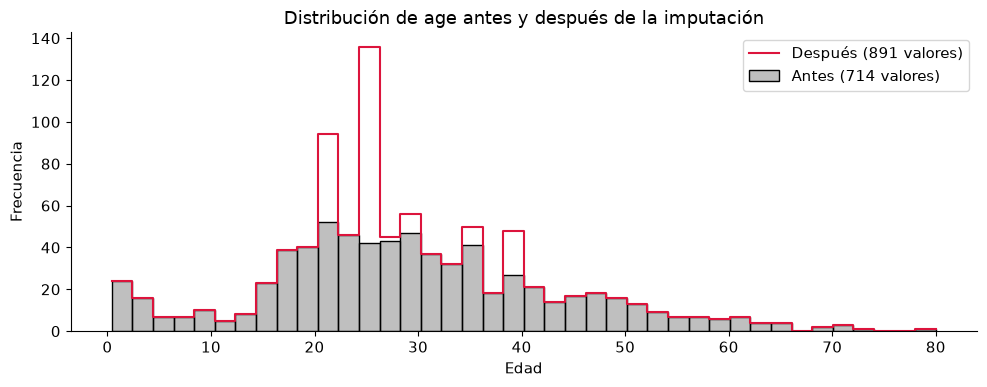

In [14]:
# ── Paso 4b: Efecto de la imputación sobre la distribución de age ────────
comparacion_age = pd.DataFrame({
    'antes (sin nulos)': df_raw['age'].dropna().describe(),
    'después (imputada)': df['age'].describe()
}).round(2)
comparacion_age.loc['asimetría'] = [df_raw['age'].skew().round(2), df['age'].skew().round(2)]
comparacion_age.loc['curtosis'] = [df_raw['age'].kurt().round(2), df['age'].kurt().round(2)]
print(comparacion_age)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df_raw['age'].dropna(), bins=40, color='grey', alpha=0.5, label='Antes (714 valores)', ax=ax)
sns.histplot(df['age'], bins=40, element='step', fill=False, color='crimson', label='Después (891 valores)', ax=ax)
ax.set_title('Distribución de age antes y después de la imputación')
ax.set_xlabel('Edad'); ax.set_ylabel('Frecuencia'); ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** la imputación conserva el rango (0,42–80 años) y desplaza levemente la media (29,7 → 29,1) y la mediana (28 → 26). Su efecto principal es **concentrar valores en las seis medianas imputadas** (21,5; 25; 28; 30; 35 y 40 años), lo que reduce la desviación estándar (14,5 → 13,3) y el rango intercuartílico (17,9 → 14,5). Por ello, las lecturas de edad posteriores se interpretan considerando estos picos artificiales.

In [15]:
# ── Paso 5: Imputar embarked con la moda ────────────────────────────────
# Solo 2 nulos (0.22%). Impacto negligible; la moda (S) es segura.
moda_emb = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(moda_emb)  # asignación explícita (compatible con pandas ≥ 2)
print(f'Puerto imputado: {moda_emb}')
print(f'Nulos en embarked tras imputación: {df["embarked"].isnull().sum()}')

Puerto imputado: S


Nulos en embarked tras imputación: 0


In [16]:
# ── Paso 6: Marcar fare=0 como inconsistencia documentada ────────────────
# No se eliminan (pueden ser tripulación o errores de registro histórico).
# Se documenta con una columna flag.
df['fare_cero_flag'] = (df['fare'] == 0).astype(int)
print(f'Registros con fare=0 (marcados): {df["fare_cero_flag"].sum()}')

Registros con fare=0 (marcados): 15


**Fuente de la tabla auxiliar de puertos (fuente web):** la tabla de metadatos geográficos de los tres puertos de embarque del Titanic (Southampton, Cherbourg y Queenstown, hoy Cobh) se publicó como archivo CSV en el repositorio del proyecto (`data/external/puertos_embarque.csv`) y se **carga directamente desde la web** con `pd.read_csv()`, igual que el dataset principal se carga desde `seaborn`. El país corresponde a la ubicación geográfica actual de cada puerto (en 1912 Queenstown formaba parte del Reino Unido de Gran Bretaña e Irlanda) y las coordenadas son las del centro de cada ciudad-puerto según Wikipedia (2026).

Antes de integrar se valida la **estructura** de la fuente (columnas y tipos esperados) y la **clave** `embarked`: debe ser única en la tabla auxiliar, para garantizar una relación muchos-a-uno sin duplicar filas, y todos los códigos del dataset deben tener correspondencia.

In [17]:
# ── Paso 7: INTEGRACIÓN — tabla auxiliar de puertos (fuente web) ───────
# Fuente auxiliar con metadatos geográficos de los puertos de embarque,
# publicada en el repositorio del proyecto y leída directamente desde GitHub.
URL_PUERTOS = ('https://raw.githubusercontent.com/k1ngdom0fbullsh1t/'
               'proyecto-grupo4-mcdi503/main/data/external/puertos_embarque.csv')
puertos = pd.read_csv(URL_PUERTOS)
print(f'Tabla auxiliar cargada desde la web: {puertos.shape}')
display(puertos)

# Validación estructural: columnas y tipos esperados
columnas_esperadas = ['embarked', 'puerto', 'pais', 'lat', 'lon']
assert list(puertos.columns) == columnas_esperadas, f'Columnas inesperadas: {list(puertos.columns)}'
assert puertos[['lat', 'lon']].apply(pd.api.types.is_numeric_dtype).all(), 'lat/lon deben ser numéricas'

# Validación de la clave: única en la tabla auxiliar y con cobertura de todas las claves del dataset
assert puertos['embarked'].is_unique, 'La clave embarked debe ser única en la tabla de puertos'
claves_sin_match = set(df['embarked'].unique()) - set(puertos['embarked'])
print(f'Claves de embarked sin correspondencia en la tabla auxiliar: {claves_sin_match or "ninguna"}')

filas_antes = len(df)
df = df.merge(puertos, on='embarked', how='left', validate='many_to_one')

# Validación post-integración
assert len(df) == filas_antes, 'La integración no debe cambiar el número de filas'
print(f'Filas antes: {filas_antes} | filas después: {len(df)}')
print('Nulos introducidos por la integración:')
print(df[['puerto','pais','lat','lon']].isnull().sum())
print(f'\nDimensiones tras integración: {df.shape}')
df[['embarked','puerto','pais']].value_counts().reset_index()

Tabla auxiliar cargada desde la web: (3, 5)


,embarked,puerto,pais,lat,lon
0,C,Cherbourg,Francia,49.6439,-1.6077
1,Q,Queenstown,Irlanda,51.8503,-8.2964
2,S,Southampton,Reino Unido,50.9025,-1.4042


Claves de embarked sin correspondencia en la tabla auxiliar: ninguna
Filas antes: 891 | filas después: 891
Nulos introducidos por la integración:
puerto    0
pais      0
lat       0
lon       0
dtype: int64

Dimensiones tras integración: (891, 14)


,embarked,puerto,pais,count
0,S,Southampton,Reino Unido,646
1,C,Cherbourg,Francia,168
2,Q,Queenstown,Irlanda,77


**Lectura:** la fuente web tiene la estructura esperada (5 columnas, coordenadas numéricas), la clave `embarked` es única en la tabla auxiliar y todos los códigos del dataset tienen correspondencia, por lo que el *merge* muchos-a-uno conserva las 891 filas y no introduce valores nulos. La coherencia semántica se verifica en la tabla anterior: cada código (C/Q/S) queda asociado a un único puerto y país, con conteos idénticos a los de `embarked`.

In [18]:
# ── Resumen del dataset limpio ────────────────────────────────────────────
print('=== DATASET LIMPIO ===')
print(f'Dimensiones: {df.shape}')
print(f'Nulos restantes:')
print(df.isnull().sum()[df.isnull().sum()>0])

=== DATASET LIMPIO ===
Dimensiones: (891, 14)
Nulos restantes:
deck    688
dtype: int64


<a id='VI'></a>
## VI. Transformaciones aplicadas y preparación del dataset

A continuación, crearemos 5 nuevas variables derivadas a partir de los datos limpios. Estas transformaciones están orientadas a simplificar la exploración gráfica y agrupar valores continuos para identificar patrones sociodemográficos de manera más clara.

### 1. Tamaño familiar total (`family_size`)
* **Cómo se crea:** Sumando las variables `sibsp` (hermanos/cónyuge) y `parch` (padres/hijos).
* **Para qué sirve:** Permite medir la magnitud total del grupo familiar del pasajero en un solo indicador numérico.
* **Por qué se hace:** Analizar por separado si la persona viajaba con padres o con hermanos fragmenta el análisis. Unificarlo en el "tamaño de la familia" nos ayudará a evaluar si viajar solo o en grupos grandes afectó la supervivencia.

In [19]:
# Creación de family_size
df['family_size'] = df['sibsp'] + df['parch']

### 2. Grupos etarios (`age_group`)
* **Cómo se crea:** Discretizando la variable `age` en rangos específicos mediante `pd.cut()` con los cortes `[0, 5, 18, 35, 60, 100]`.
* **Para qué sirve:** Transforma la edad (variable numérica continua) en categorías de ciclo de vida (niños, adolescentes, adultos, etc.).
* **Por qué se hace:** La supervivencia en desastres a menudo prioriza a grupos específicos (como los niños). Agrupar las edades nos permite ver el efecto de estas políticas de rescate de forma mucho más nítida que analizando la edad año por año.

In [20]:
# Creación de age_group
df['age_group'] = pd.cut(df['age'], bins=[0, 5, 18, 35, 60, 100],
                         labels=['0-5 años', '6-18 años', '19-35 años', '36-60 años', '61+ años'])

### 3. Tramos de tarifa (`fare_bin`)
* **Cómo se crea:** Segmentando la variable `fare` en 4 cuantiles (grupos con la misma cantidad de observaciones) mediante `pd.qcut(..., q=4)`.
* **Para qué sirve:** Agrupa el costo del pasaje en 4 niveles de poder adquisitivo (Q1 a Q4).
* **Por qué se hace:** Como descubriremos más adelante, la tarifa tiene un sesgo extremo y valores atípicos muy altos. Usar cuantiles suaviza estos extremos y divide equitativamente a los pasajeros según lo que pagaron, facilitando el análisis bivariado.

In [21]:
# Creación de fare_bin
df['fare_bin'] = pd.qcut(df['fare'], q=4,
                         labels=['Q1 (Bajo)', 'Q2 (Medio-bajo)', 'Q3 (Medio-alto)', 'Q4 (Alto)'])

### 4. Etiqueta de supervivencia (`survived_label`)
* **Cómo se crea:** Mapeando los valores `0` y `1` de la columna `survived` a textos legibles.
* **Para qué sirve:** Traduce el código binario a etiquetas de texto ('No sobrevivió', 'Sobrevivió').
* **Por qué se hace:** Facilita la generación de visualizaciones directas y autoexplicativas. Mejora la legibilidad de los gráficos para audiencias no técnicas.

In [22]:
# Creación de survived_label
df['survived_label'] = df['survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})

# Verificamos las transformaciones
display(df[['family_size', 'age_group', 'fare_bin', 'survived_label']].head())

,family_size,age_group,fare_bin,survived_label
0,1,19-35 años,Q1 (Bajo),No sobrevivió
1,1,36-60 años,Q4 (Alto),Sobrevivió
2,0,19-35 años,Q2 (Medio-bajo),Sobrevivió
3,1,19-35 años,Q4 (Alto),Sobrevivió
4,0,19-35 años,Q2 (Medio-bajo),No sobrevivió


### 5. Indicador de viaje sin familia (`viaja_solo`)
* **Cómo se crea:** Asignando 'Solo' cuando `family_size == 0` y 'Con familia' en caso contrario.
* **Para qué sirve:** Permite comparar directamente a quienes viajaban sin familiares frente a quienes viajaban acompañados.
* **Por qué se hace:** Reemplaza de forma explícita y trazable a la columna `alone` eliminada en la Sección V (equivalente, pero construida por el equipo a partir de `family_size` y con etiquetas legibles). Se usa en la Sección IX para controlar el efecto de viajar solo por sexo.

In [23]:
# Creación de viaja_solo
df['viaja_solo'] = np.where(df['family_size'] == 0, 'Solo', 'Con familia')

# Verificación de equivalencia con la columna original 'alone' de seaborn
print('¿viaja_solo coincide con alone original?',
      ((df['viaja_solo'] == 'Solo') == df_raw['alone']).all())

¿viaja_solo coincide con alone original? True


### Verificación de las transformaciones
Se comprueba que las variables derivadas no generan valores faltantes, que las categorías cubren a todos los pasajeros y se muestran los cortes efectivos de `fare_bin`.

In [24]:
nuevas = ['family_size', 'age_group', 'fare_bin', 'survived_label', 'viaja_solo']
print('Nulos en variables derivadas:', df[nuevas].isnull().sum().to_dict())

_, cortes_fare = pd.qcut(df['fare'], q=4, retbins=True)
print('Cortes de fare_bin (cuartiles):', np.round(cortes_fare, 2).tolist())

for col in ['age_group', 'fare_bin', 'viaja_solo']:
    print(f'\n{col}:', df[col].value_counts(sort=False).to_dict())

print(f'\nRango de family_size: {df["family_size"].min()} a {df["family_size"].max()}')
print(f'Dimensiones del dataset preparado: {df.shape}')

Nulos en variables derivadas: {'family_size': 0, 'age_group': 0, 'fare_bin': 0, 'survived_label': 0, 'viaja_solo': 0}
Cortes de fare_bin (cuartiles): [0.0, 7.91, 14.45, 31.0, 512.33]

age_group: {'0-5 años': 44, '6-18 años': 95, '19-35 años': 514, '36-60 años': 216, '61+ años': 22}

fare_bin: {'Q1 (Bajo)': 223, 'Q2 (Medio-bajo)': 224, 'Q3 (Medio-alto)': 222, 'Q4 (Alto)': 222}

viaja_solo: {'Con familia': 354, 'Solo': 537}

Rango de family_size: 0 a 10
Dimensiones del dataset preparado: (891, 19)


<a id='VII'></a>
## VII. Análisis univariado

En esta etapa exploraremos la distribución individual de las variables más relevantes del dataset para comprender la composición demográfica y estructural de los pasajeros a bordo del Titanic.

### 0. Medidas descriptivas generales
Antes de revisar cada variable se resumen las medidas descriptivas básicas (media, desviación estándar, cuartiles) y robustas (mediana, rango intercuartílico), junto con la asimetría y la curtosis de las variables numéricas, y las frecuencias relativas de las variables categóricas.

In [25]:
# Variables numéricas: medidas básicas y robustas
num_cols = ['age', 'fare', 'sibsp', 'parch', 'family_size']
desc_num = df[num_cols].describe().T
desc_num['mediana'] = df[num_cols].median()
desc_num['IQR'] = desc_num['75%'] - desc_num['25%']
desc_num['asimetría'] = df[num_cols].skew()
desc_num['curtosis'] = df[num_cols].kurt()
print('=== VARIABLES NUMÉRICAS ===')
print(desc_num[['count', 'mean', 'std', 'min', '25%', 'mediana', '75%', 'max', 'IQR', 'asimetría', 'curtosis']]
      .round(2).to_string())

# Variables categóricas: frecuencias absolutas y relativas
print('\n=== VARIABLES CATEGÓRICAS ===')
for col in ['survived_label', 'pclass', 'sex', 'embarked', 'age_group', 'viaja_solo']:
    tabla = pd.DataFrame({
        'n': df[col].value_counts(sort=False),
        '%': df[col].value_counts(normalize=True, sort=False).mul(100).round(1)
    })
    print(f'\n{col}:')
    print(tabla.to_string())

=== VARIABLES NUMÉRICAS ===
             count   mean    std   min    25%  mediana   75%     max    IQR  asimetría  curtosis
age          891.0  29.11  13.30  0.42  21.50    26.00  36.0   80.00  14.50       0.53      0.72
fare         891.0  32.20  49.69  0.00   7.91    14.45  31.0  512.33  23.09       4.79     33.40
sibsp        891.0   0.52   1.10  0.00   0.00     0.00   1.0    8.00   1.00       3.70     17.88
parch        891.0   0.38   0.81  0.00   0.00     0.00   0.0    6.00   0.00       2.75      9.78
family_size  891.0   0.90   1.61  0.00   0.00     0.00   1.0   10.00   1.00       2.73      9.16

=== VARIABLES CATEGÓRICAS ===

survived_label:
                  n     %
survived_label           
No sobrevivió   549  61.6
Sobrevivió      342  38.4

pclass:
          n     %
pclass           
3       491  55.1
1       216  24.2
2       184  20.7

sex:
          n     %
sex              
male    577  64.8
female  314  35.2

embarked:
            n     %
embarked           
S         

**Lectura:** `fare` es la variable más asimétrica (asimetría ≈ 4,8; curtosis ≈ 33): su media (32,2) duplica la mediana (14,45), por lo que la **mediana y el IQR** son las medidas de tendencia central y dispersión más representativas. `sibsp`, `parch` y `family_size` también son asimétricas a la derecha, con mediana 0 (la mayoría viaja sin familia). `age`, ya imputada, es aproximadamente simétrica (asimetría ≈ 0,5), con mediana de 26 años. En las categóricas, el 61,6% no sobrevivió, el 64,8% son hombres, el 55,1% viaja en Tercera Clase y el 72,5% embarcó en Southampton.

### 1. Variable objetivo: `survived`
**¿Cuál es la proporción general de pasajeros que sobrevivieron al naufragio?**

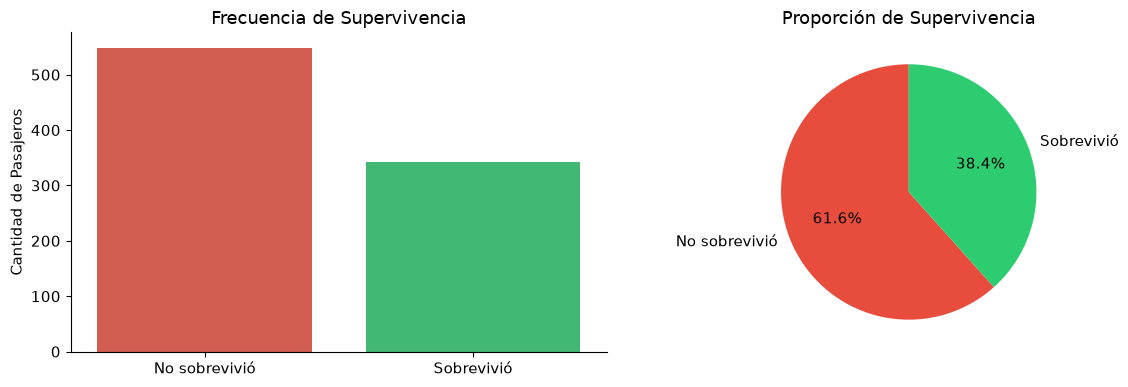

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Vinculamos las nuevas etiquetas en español con los colores de la PALETTE global
paleta_supervivencia = {
    'No sobrevivió': PALETTE['not_survived'],
    'Sobrevivió': PALETTE['survived']
}

# Gráfico de barras
sns.countplot(data=df, x='survived_label', palette=paleta_supervivencia, ax=axes[0])
axes[0].set_title('Frecuencia de Supervivencia')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Pasajeros')

# Gráfico de torta (asegurando el orden correcto de los colores)
df['survived_label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=[paleta_supervivencia[idx] for idx in df['survived_label'].value_counts().index],
    ax=axes[1], startangle=90, ylabel=''
)
axes[1].set_title('Proporción de Supervivencia')

plt.tight_layout()
plt.show()

**Interpretación:** La mayoría de los pasajeros en el dataset no sobrevivió. Aproximadamente el 61.6% de las personas perdieron la vida, estableciendo un claro desbalance en nuestra variable objetivo que contextualiza la magnitud de la tragedia.

### 2. Variable: `pclass`
**¿Cómo se distribuyen los pasajeros según su clase de viaje?**

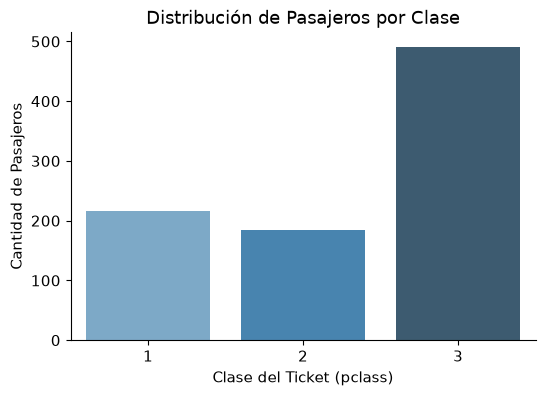

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='pclass', palette='Blues_d')
plt.title('Distribución de Pasajeros por Clase')
plt.xlabel('Clase del Ticket (pclass)')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

**Interpretación:** La Tercera Clase (3) agrupa a la abrumadora mayoría de los pasajeros, superando por sí sola la suma de los pasajeros de Primera y Segunda clase. Esto refleja la estructura socioeconómica de la época, donde la mayoría viajaba en las cubiertas inferiores buscando emigrar.

### 3. Variable: `sex`
**¿Cuál es la composición por género de los pasajeros a bordo?**

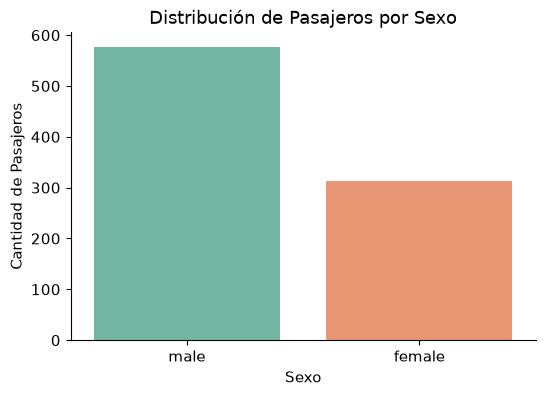

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', palette='Set2')
plt.title('Distribución de Pasajeros por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

**Interpretación:** El Titanic transportaba predominantemente hombres. Existen casi el doble de pasajeros masculinos que femeninos en nuestra muestra, lo que jugará un rol crucial al analizar las tasas de supervivencia bajo la política de "mujeres y niños primero".

### 4. Variable: `age`
**¿Cómo se distribuyen las edades de los pasajeros?**

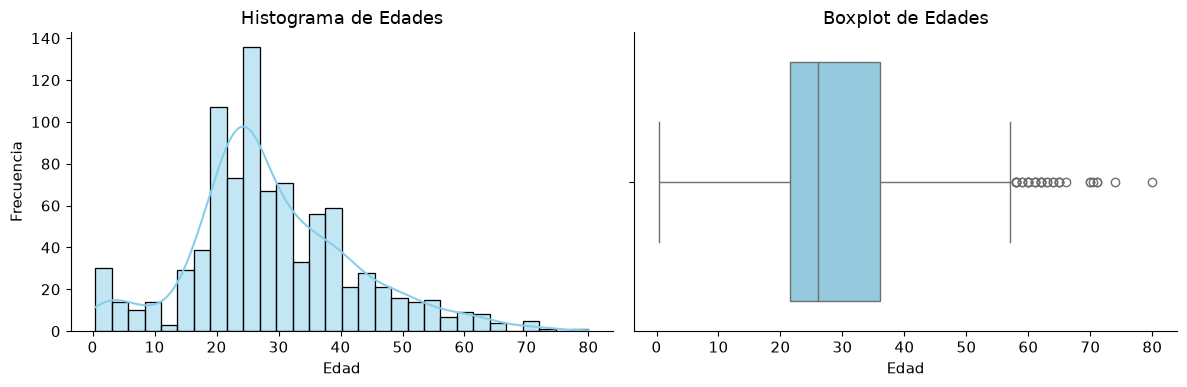

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
sns.histplot(data=df, x='age', kde=True, bins=30, color='skyblue', ax=axes[0])
axes[0].set_title('Histograma de Edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(data=df, x='age', color='skyblue', ax=axes[1])
axes[1].set_title('Boxplot de Edades')
axes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

**Interpretación:** La distribución de la edad (ya imputada) concentra su mayor volumen entre los 20 y los 38 años, con mediana de 26 años. Presenta una ligera asimetría hacia la derecha provocada por un segmento menor de adultos mayores: el boxplot marca como atípicos a los pasajeros sobre ~58 años (límite superior del criterio IQR), y se observa un grupo de niños pequeños (0 a 5 años). Los picos visibles en el histograma alrededor de 21,5, 25, 30, 35 y 40 años se deben en parte a la imputación por medianas (ver Paso 4b de la Sección V).

### 5. Variable: `fare`
**¿Cuál es la distribución de las tarifas pagadas por los pasajeros?**

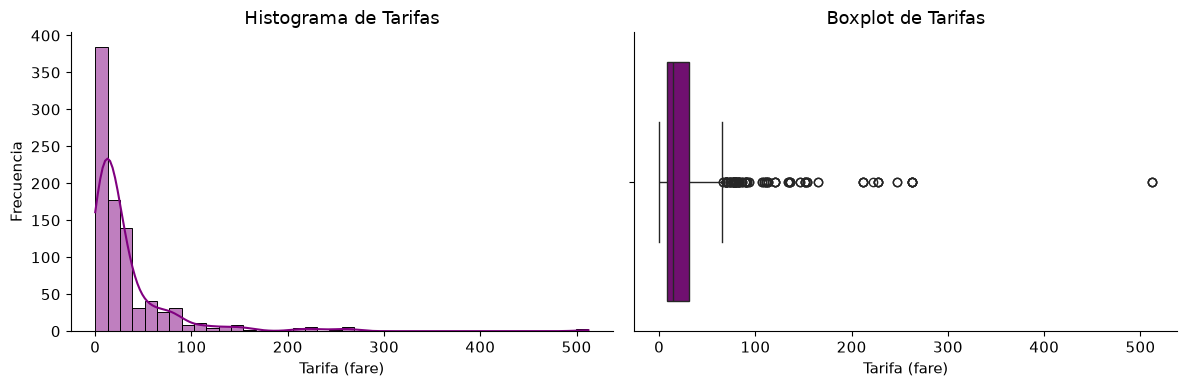

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
sns.histplot(data=df, x='fare', kde=True, bins=40, color='purple', ax=axes[0])
axes[0].set_title('Histograma de Tarifas')
axes[0].set_xlabel('Tarifa (fare)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(data=df, x='fare', color='purple', ax=axes[1])
axes[1].set_title('Boxplot de Tarifas')
axes[1].set_xlabel('Tarifa (fare)')

plt.tight_layout()
plt.show()

**Interpretación:** La variable tarifa (`fare`) presenta un sesgo positivo extremo (cola pesada hacia la derecha). La gran mayoría de los boletos costaron menos de 50 unidades, pero existen valores atípicos (outliers) masivos que superan las 500 unidades, representando boletos de lujo ultra-exclusivos.

### 6. Variable: `embarked`
**¿Desde qué puertos embarcó la mayor cantidad de pasajeros?**

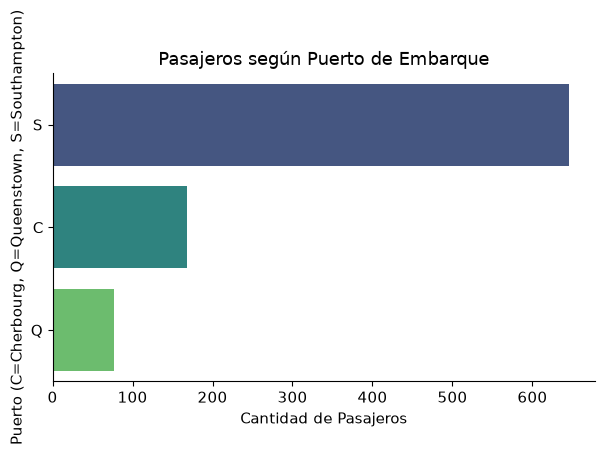

In [31]:
plt.figure(figsize=(7, 4))
# Se usa el código original de embarked; el nombre del puerto integrado se utiliza en la Sección VIII
sns.countplot(data=df, y='embarked', palette='viridis', order=df['embarked'].value_counts().index)
plt.title('Pasajeros según Puerto de Embarque')
plt.xlabel('Cantidad de Pasajeros')
plt.ylabel('Puerto (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.show()

**Interpretación:** Southampton ('S') fue, con gran diferencia, el puerto de origen de la mayoría de los pasajeros, seguido por Cherbourg ('C') y, por último, Queenstown ('Q').

### 7. Variable: `family_size`
**¿Cuál era el tamaño familiar típico de los pasajeros a bordo?**

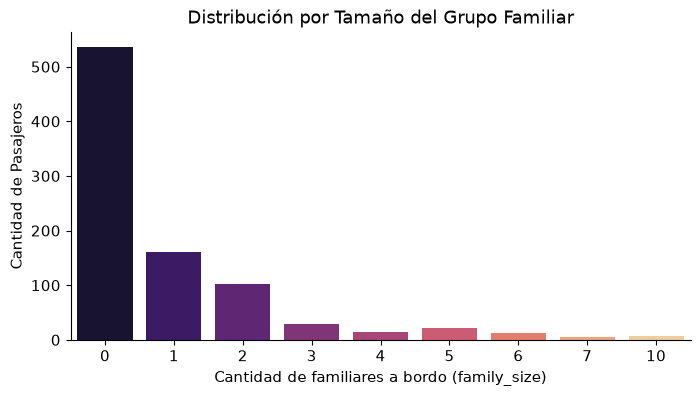

In [32]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='family_size', palette='magma')
plt.title('Distribución por Tamaño del Grupo Familiar')
plt.xlabel('Cantidad de familiares a bordo (family_size)')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

**Interpretación:** La inmensa mayoría de los pasajeros viajaba completamente sola (tamaño familiar = 0). Las familias de 1 a 3 integrantes formaban el segundo grupo más común, mientras que las familias numerosas (más de 4 familiares) representaban casos excepcionales.

### 8. Variable: `age_group`
**¿Qué grupo etario predominaba en el Titanic?**

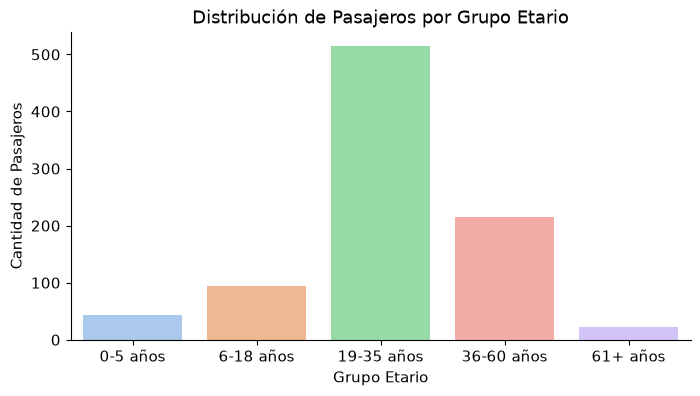

In [33]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='age_group', palette='pastel')
plt.title('Distribución de Pasajeros por Grupo Etario')
plt.xlabel('Grupo Etario')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

**Interpretación:** Consistente con el histograma de edades, el análisis de rangos revela que los "Adultos Jóvenes" (19-35 años) dominaban ampliamente la demografía del barco. Los adolescentes y los adultos maduros tienen representaciones intermedias, mientras que los bebés/niños y adultos mayores son la minoría.

<a id='VIII'></a>
## VIII. Análisis bivariado

En esta sección se analizan las relaciones entre la variable objetivo `survived` y los principales predictores del dataset. Se utilizan tasas de supervivencia, distribuciones y gráficos comparativos para identificar diferencias y patrones entre los grupos.

### 1. Supervivencia según sexo

**¿Existen diferencias en la tasa de supervivencia entre hombres y mujeres?**

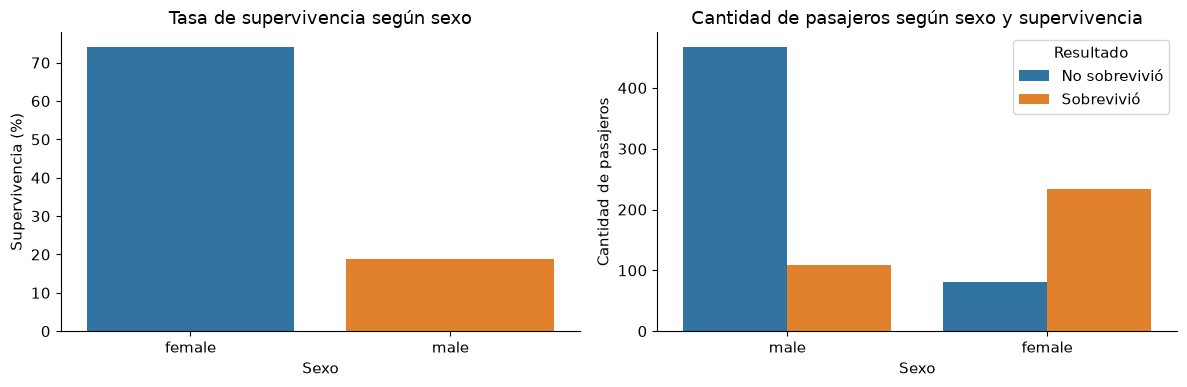

      sex  tasa_supervivencia
0  female           74.203822
1    male           18.890815


In [34]:
# Tasa de supervivencia por sexo
tasa_sexo = (
    df.groupby('sex')['survived']
      .mean()
      .mul(100)
      .reset_index(name='tasa_supervivencia')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tasa de supervivencia
sns.barplot(
    data=tasa_sexo,
    x='sex',
    y='tasa_supervivencia',
    hue='sex',
    legend=False,
    ax=axes[0]
)

axes[0].set_title('Tasa de supervivencia según sexo')
axes[0].set_xlabel('Sexo')
axes[0].set_ylabel('Supervivencia (%)')

# Countplot
sns.countplot(
    data=df,
    x='sex',
    hue='survived_label',
    ax=axes[1]
)

axes[1].set_title('Cantidad de pasajeros según sexo y supervivencia')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].legend(title='Resultado')

plt.tight_layout()
plt.show()

print(tasa_sexo)

**Interpretación:** Se observa una diferencia marcada en la supervivencia según sexo: el **74,2%** de las mujeres sobrevivió frente al **18,9%** de los hombres. Aunque había más pasajeros hombres a bordo, la brecha es muy amplia, por lo que el sexo presenta una asociación clara con la supervivencia en este dataset.

### 2. Supervivencia según clase de viaje

**¿Cómo cambia la tasa de supervivencia entre las distintas clases del Titanic?**

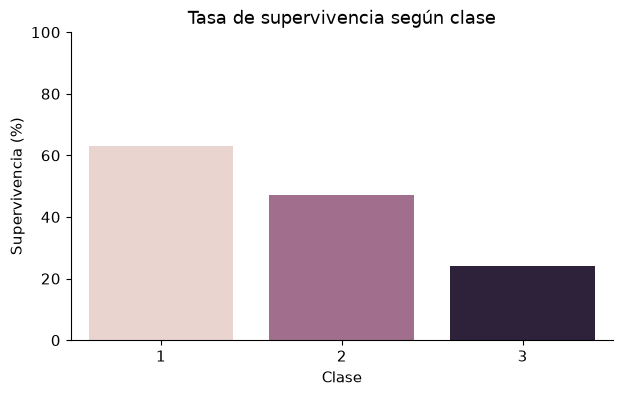

   pclass  tasa_supervivencia
0       1           62.962963
1       2           47.282609
2       3           24.236253


In [35]:
tasa_pclass = (
    df.groupby('pclass')['survived']
      .mean()
      .mul(100)
      .reset_index(name='tasa_supervivencia')
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=tasa_pclass,
    x='pclass',
    y='tasa_supervivencia',
    hue='pclass',
    legend=False
)

plt.title('Tasa de supervivencia según clase')
plt.xlabel('Clase')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)

plt.show()

print(tasa_pclass)

**Interpretación:** La tasa de supervivencia disminuye a medida que baja la clase de viaje: **63,0%** en Primera Clase, **47,3%** en Segunda y **24,2%** en Tercera. Esto evidencia una asociación entre la clase de viaje y la supervivencia observada en el dataset.

### 3. Supervivencia según edad

**¿Existen diferencias en la distribución de edad entre quienes sobrevivieron y quienes no sobrevivieron?**

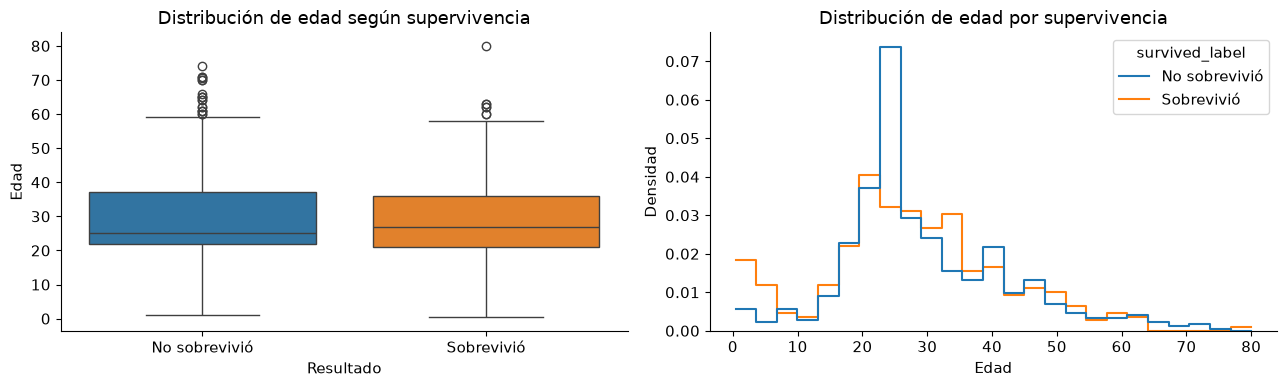

survived_label
No sobrevivió    25.0
Sobrevivió       27.0
Name: age, dtype: float64


In [36]:
# ── 3. Supervivencia según edad ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(
    data=df,
    x='survived_label',
    y='age',
    hue='survived_label',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Distribución de edad según supervivencia')
axes[0].set_xlabel('Resultado')
axes[0].set_ylabel('Edad')

sns.histplot(
    data=df,
    x='age',
    hue='survived_label',
    bins=25,
    stat='density',
    common_norm=False,
    element='step',
    fill=False,
    ax=axes[1]
)
axes[1].set_title('Distribución de edad por supervivencia')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

print(df.groupby('survived_label')['age'].median())

**Interpretación:** La mediana de edad es muy parecida entre quienes sobrevivieron (27 años) y quienes no (25 años), por lo que la edad por sí sola no separa bien a los grupos. La diferencia aparece en los extremos: los niños pequeños tienen mayor presencia entre los sobrevivientes, lo que se aprecia mejor al agrupar por `age_group`.

### 4. Supervivencia según tarifa

**¿Cómo se distribuye la tarifa entre quienes sobrevivieron y quienes no sobrevivieron?**

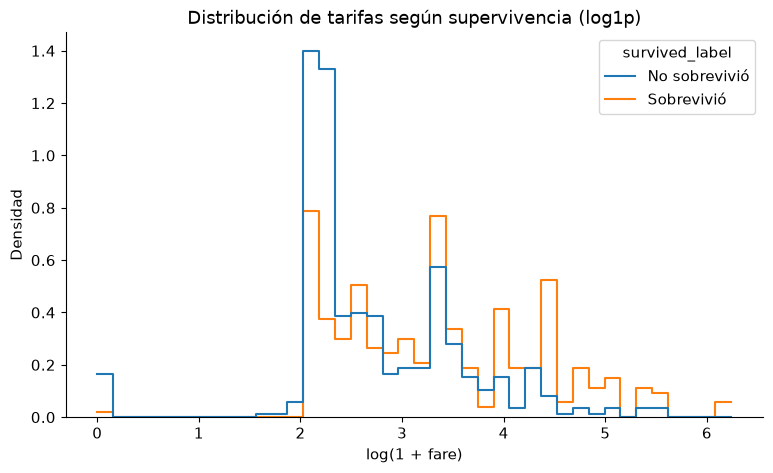

In [37]:
# ── 4. Supervivencia según tarifa (escala log1p por el sesgo) ───────────
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df.assign(log_fare=np.log1p(df['fare'])),
    x='log_fare',
    hue='survived_label',
    bins=40,
    stat='density',
    common_norm=False,
    element='step',
    fill=False
)

plt.title('Distribución de tarifas según supervivencia (log1p)')
plt.xlabel('log(1 + fare)')
plt.ylabel('Densidad')
plt.show()

**Interpretación:** La distribución de `fare` presenta un fuerte sesgo positivo, por lo que se muestra en escala logarítmica (`log1p`). Al comparar ambos grupos se observa una mayor presencia relativa de tarifas elevadas entre quienes sobrevivieron. Esto es consistente con la relación observada entre tarifa y clase de viaje, por lo que `fare` puede estar capturando parcialmente diferencias socioeconómicas asociadas a `pclass`.

              n  tasa
age_group            
0-5 años     44  70.5
6-18 años    95  41.1
19-35 años  514  35.8
36-60 años  216  38.4
61+ años     22  22.7 

                   n  tasa
fare_bin                  
Q1 (Bajo)        223  19.7
Q2 (Medio-bajo)  224  30.4
Q3 (Medio-alto)  222  45.5
Q4 (Alto)        222  58.1 



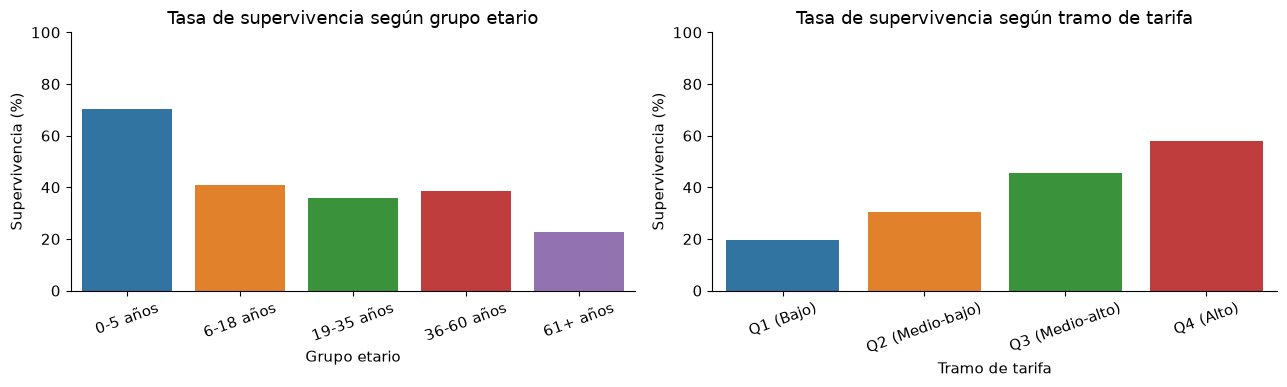

In [38]:
# ── Supervivencia según grupo etario y tramo de tarifa ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in zip(axes, ['age_group', 'fare_bin'], ['grupo etario', 'tramo de tarifa']):
    tasa = (
        df.groupby(col, observed=True)['survived']
          .mean()
          .mul(100)
          .reset_index(name='tasa_supervivencia')
    )
    sns.barplot(data=tasa, x=col, y='tasa_supervivencia', hue=col, legend=False, ax=ax)
    ax.set_title(f'Tasa de supervivencia según {titulo}')
    ax.set_xlabel(titulo.capitalize())
    ax.set_ylabel('Supervivencia (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)

    print(
        df.groupby(col, observed=True)['survived']
          .agg(n='count', tasa=lambda s: s.mean() * 100)
          .round(1),
        '\n'
    )

plt.tight_layout()
plt.show()

**Interpretación:** Los niños de 0 a 5 años presentan la mayor tasa de supervivencia (**70,5%**), y luego la tasa baja a 41,1% en el grupo de 6 a 18 años, 35,8% en 19 a 35 años y 38,4% en 36 a 60 años. El grupo de 61 años o más tiene la menor tasa (**22,7%**), aunque con solo 22 pasajeros. Por tramo de tarifa, la supervivencia aumenta de forma sostenida: **19,7%** en Q1, 30,4% en Q2, 45,5% en Q3 y **58,1%** en Q4, lo que es consistente con la relación entre tarifa y clase de viaje.

### 5. Supervivencia según tamaño familiar

**¿Existe una diferencia en la tasa de supervivencia según el tamaño del grupo familiar?**

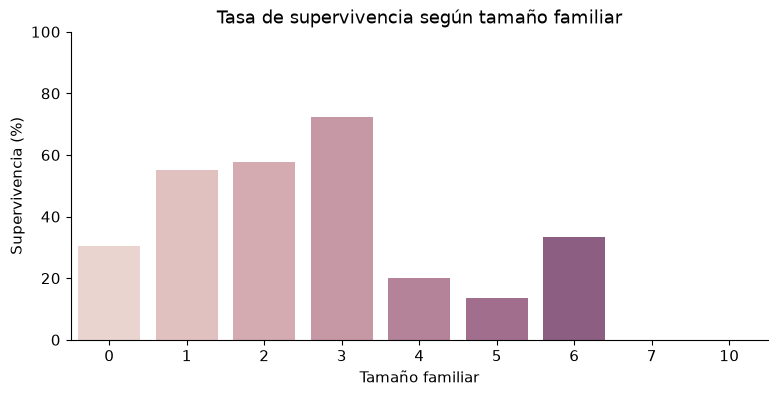

   family_size  tasa_supervivencia
0            0           30.353818
1            1           55.279503
2            2           57.843137
3            3           72.413793
4            4           20.000000
5            5           13.636364
6            6           33.333333
7            7            0.000000
8           10            0.000000


In [39]:
tasa_familia = (
    df.groupby('family_size')['survived']
      .mean()
      .mul(100)
      .reset_index(name='tasa_supervivencia')
)

plt.figure(figsize=(9, 4))

sns.barplot(
    data=tasa_familia,
    x='family_size',
    y='tasa_supervivencia',
    hue='family_size',
    legend=False
)

plt.title('Tasa de supervivencia según tamaño familiar')
plt.xlabel('Tamaño familiar')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)

plt.show()

print(tasa_familia)

**Interpretación:** La tasa de supervivencia no presenta un comportamiento lineal respecto al tamaño familiar. Los grupos de 3 integrantes alcanzan la mayor tasa (**72,4%**), mientras que los pasajeros que viajan solos tienen **30,4%** y los grupos muy numerosos (≥5) caen por debajo del **20%**, posiblemente por dificultades de coordinación durante la evacuación.

### 6. Supervivencia según puerto de embarque

**¿Existen diferencias en la tasa de supervivencia según el puerto de embarque?**

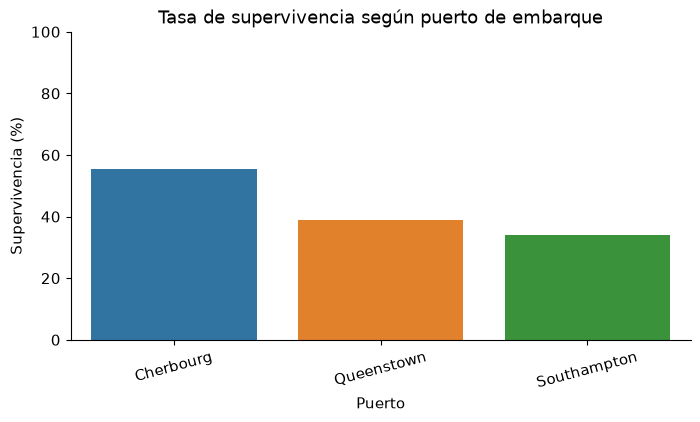

  embarked       puerto  tasa_supervivencia
0        C    Cherbourg           55.357143
1        Q   Queenstown           38.961039
2        S  Southampton           33.900929


In [40]:
tasa_embarked = (
    df.groupby(['embarked', 'puerto'])['survived']
      .mean()
      .mul(100)
      .reset_index(name='tasa_supervivencia')
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=tasa_embarked,
    x='puerto',
    y='tasa_supervivencia',
    hue='puerto',
    legend=False
)

plt.title('Tasa de supervivencia según puerto de embarque')
plt.xlabel('Puerto')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.show()

print(tasa_embarked)

**Interpretación:** Cherbourg presenta la mayor tasa de supervivencia (**55,4%**), seguido de Queenstown (**39,0%**) y Southampton (**33,9%**). Estas diferencias deben interpretarse con cautela, ya que el puerto también puede estar relacionado con la composición de los pasajeros y con variables como la clase de viaje y el sexo.

### 7. Interacción entre sexo y clase

**¿Cómo cambia la tasa de supervivencia al combinar sexo y clase de viaje?**

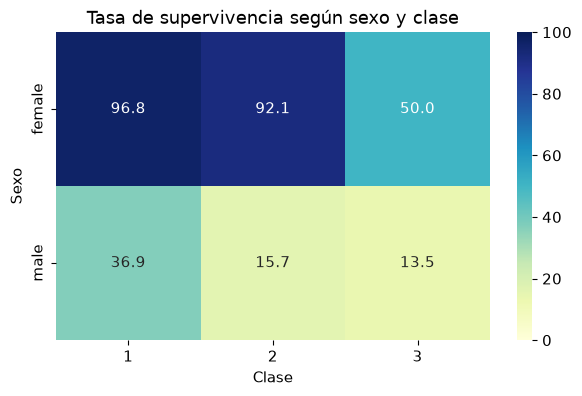

In [41]:
heatmap_sexo_clase = (
    df.groupby(['sex', 'pclass'])['survived']
      .mean()
      .mul(100)
      .unstack()
)

plt.figure(figsize=(7, 4))

sns.heatmap(
    heatmap_sexo_clase,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0,
    vmax=100
)

plt.title('Tasa de supervivencia según sexo y clase')
plt.xlabel('Clase')
plt.ylabel('Sexo')

plt.show()

**Interpretación:** El heatmap muestra que la supervivencia no depende únicamente del sexo ni de la clase por separado. Las mujeres de Primera y Segunda Clase superan el 90% de supervivencia (**96,8%** y **92,1%**), mientras que las de Tercera Clase bajan a **50,0%**. En los hombres, ninguna clase supera el 37% (**36,9%** en Primera, **15,7%** en Segunda y **13,5%** en Tercera). La combinación de ambas variables permite ver con mayor claridad la estructura de la supervivencia.

### 8. Correlación entre variables numéricas

**¿Qué relaciones lineales se observan entre las principales variables numéricas del dataset?**

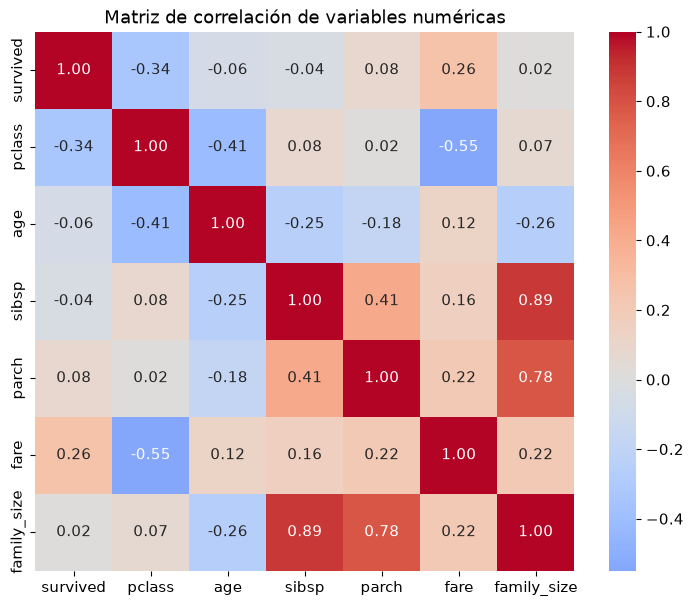

In [42]:
variables_numericas = [
    'survived',
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
    'family_size'
]

corr = df[variables_numericas].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Matriz de correlación de variables numéricas')

plt.show()

**Interpretación:** Las asociaciones lineales más fuertes con `survived` son `pclass` (**−0,34**) y `fare` (**0,26**). Las demás son prácticamente nulas: `age` (−0,06), `sibsp` (−0,04), `parch` (0,08) y `family_size` (0,02), lo que no descarta relaciones no lineales como la observada en `family_size`. La alta correlación entre `family_size`, `sibsp` y `parch` es esperable, porque la primera se construye a partir de las otras dos. Estas asociaciones no implican causalidad.

<a id='IX'></a>
## IX. Patrones, anomalías y hallazgos iniciales

En esta sección se revisan patrones relevantes, valores atípicos y posibles anomalías identificadas durante el análisis exploratorio. Se distinguen los comportamientos observados de posibles errores o particularidades del registro histórico.

### 1. Outliers en `fare`

**¿Cuántos valores atípicos presenta `fare` según el criterio del rango intercuartílico (IQR)?**

Q1: 7.91
Q3: 31.00
IQR: 23.09
Límite inferior: -26.72
Límite superior: 65.63
Cantidad de outliers: 116


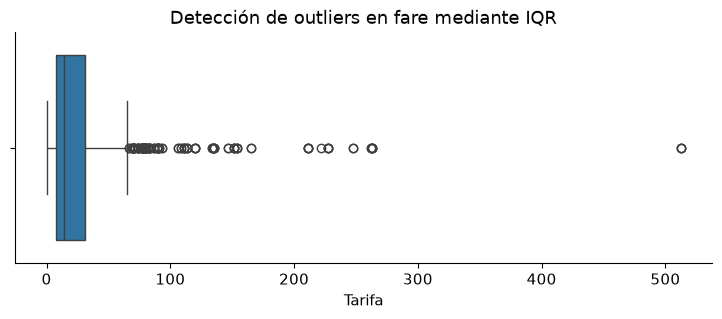

In [43]:
# Cálculo de outliers mediante el criterio IQR

Q1_fare = df['fare'].quantile(0.25)
Q3_fare = df['fare'].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

limite_inferior = Q1_fare - 1.5 * IQR_fare
limite_superior = Q3_fare + 1.5 * IQR_fare

outliers_fare = df[
    (df['fare'] < limite_inferior) |
    (df['fare'] > limite_superior)
]

print(f"Q1: {Q1_fare:.2f}")
print(f"Q3: {Q3_fare:.2f}")
print(f"IQR: {IQR_fare:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Cantidad de outliers: {len(outliers_fare)}")

plt.figure(figsize=(9, 3))
sns.boxplot(x=df['fare'])
plt.title('Detección de outliers en fare mediante IQR')
plt.xlabel('Tarifa')
plt.show()

#### Caracterización de los outliers: clase, resumen estadístico y tarifas máximas

In [44]:
# Caracterización de los outliers de fare

print("Distribución de los outliers según clase:")
print(outliers_fare['pclass'].value_counts().sort_index())

print("\nResumen de fare entre los outliers:")
print(outliers_fare['fare'].describe())

print("\nMáximas tarifas entre los outliers:")
print(
    outliers_fare[['pclass', 'sex', 'fare']]
    .sort_values('fare', ascending=False)
    .head(10)
)

Distribución de los outliers según clase:
pclass
1    104
2      5
3      7
Name: count, dtype: int64

Resumen de fare entre los outliers:
count    116.000000
mean     128.291629
std       84.636908
min       66.600000
25%       78.189600
50%       90.000000
75%      147.778100
max      512.329200
Name: fare, dtype: float64

Máximas tarifas entre los outliers:
     pclass     sex      fare
258       1  female  512.3292
737       1    male  512.3292
679       1    male  512.3292
27        1    male  263.0000
341       1  female  263.0000
438       1    male  263.0000
88        1  female  263.0000
311       1  female  262.3750
742       1  female  262.3750
299       1  female  247.5208


### Interpretación

El criterio del rango intercuartílico (IQR) identifica **116 valores atípicos** en `fare`, utilizando un límite superior de **65,63**. La mayoría de estos registros corresponde a pasajeros de **Primera Clase (104 de 116)**, aunque también se identifican 5 pasajeros de Segunda Clase y 7 de Tercera Clase.

Los valores identificados alcanzan una tarifa máxima de **512,33**, mostrando una distribución con valores extremos y un sesgo positivo. Estos registros no deben eliminarse automáticamente, ya que representan tarifas observadas en el dataset y pueden contener información relevante sobre las diferencias económicas entre los pasajeros. Por lo tanto, se consideran **valores atípicos estadísticos y no necesariamente errores de registro**.



### 2. Outliers en `age`: pasajeros de edad avanzada

**¿Cuántos pasajeros tienen 60 años o más y cuántos superan los 65 años?**

Pasajeros con 60 años o más: 26
Pasajeros con más de 65 años: 8

Edades máximas registradas:
      age   sex  pclass  survived
630  80.0  male       1         1
851  74.0  male       3         0
96   71.0  male       1         0
493  71.0  male       1         0
116  70.5  male       3         0
672  70.0  male       2         0
745  70.0  male       1         0
33   66.0  male       2         0
54   65.0  male       1         0
280  65.0  male       3         0


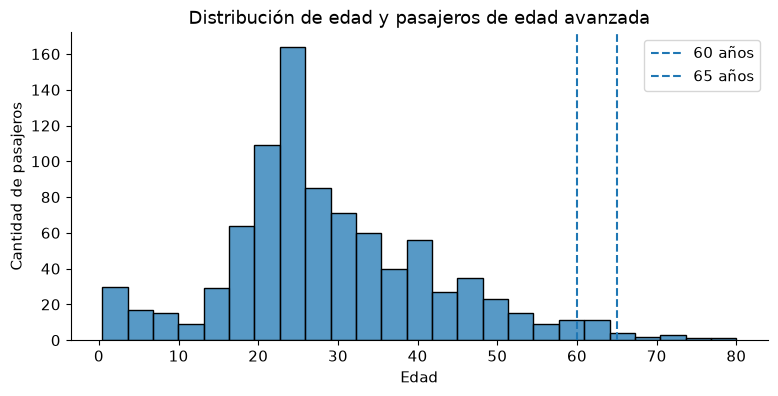

In [45]:
# Identificación de pasajeros de edad avanzada

mayores_60 = df[df['age'] >= 60]
mayores_65 = df[df['age'] > 65]

print(f"Pasajeros con 60 años o más: {len(mayores_60)}")
print(f"Pasajeros con más de 65 años: {len(mayores_65)}")

print("\nEdades máximas registradas:")
print(
    df[['age', 'sex', 'pclass', 'survived']]
    .sort_values('age', ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 4))

sns.histplot(
    data=df,
    x='age',
    bins=25
)

plt.axvline(60, linestyle='--', label='60 años')
plt.axvline(65, linestyle='--', label='65 años')

plt.title('Distribución de edad y pasajeros de edad avanzada')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.legend()

plt.show()

### Interpretación

Se identifican **26 pasajeros con 60 años o más**, de los cuales **8 tienen más de 65 años**. Se trata de un grupo reducido dentro del dataset, por lo que estas edades se encuentran en la parte superior de la distribución y constituyen observaciones poco frecuentes.

De los 8 pasajeros mayores de 65 años, **7 no sobrevivieron**; el único sobreviviente es el pasajero de 80 años, el de mayor edad del dataset.

La presencia de pasajeros de edad avanzada debe considerarse al interpretar la distribución de `age`, pero no constituye por sí misma un error o dato inválido. Estas observaciones se mantienen en el dataset debido a que representan pasajeros reales registrados en la muestra histórica.



### 3. Registros con `fare = 0`

**¿Qué características presentan los pasajeros con tarifa igual a cero y cómo deben tratarse estos registros?**

In [46]:
# Caracterización de registros con fare = 0

fare_cero = df[df['fare'] == 0].copy()

print(f"Cantidad de registros con fare = 0: {len(fare_cero)}")

print("\nDistribución por clase:")
print(fare_cero['pclass'].value_counts().sort_index())

print("\nDistribución por sexo:")
print(fare_cero['sex'].value_counts())

print("\nDistribución según supervivencia:")
print(fare_cero['survived_label'].value_counts())

print("\nDetalle de los registros:")
display(
    fare_cero[
        ['survived', 'pclass', 'sex', 'age', 'sibsp',
         'parch', 'fare', 'embarked', 'fare_cero_flag']
    ]
)

Cantidad de registros con fare = 0: 15

Distribución por clase:
pclass
1    5
2    6
3    4
Name: count, dtype: int64

Distribución por sexo:
sex
male    15
Name: count, dtype: int64

Distribución según supervivencia:
survived_label
No sobrevivió    14
Sobrevivió        1
Name: count, dtype: int64

Detalle de los registros:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,fare_cero_flag
179,0,3,male,36.0,0,0,0.0,S,1
263,0,1,male,40.0,0,0,0.0,S,1
271,1,3,male,25.0,0,0,0.0,S,1
277,0,2,male,30.0,0,0,0.0,S,1
302,0,3,male,19.0,0,0,0.0,S,1
413,0,2,male,30.0,0,0,0.0,S,1
466,0,2,male,30.0,0,0,0.0,S,1
481,0,2,male,30.0,0,0,0.0,S,1
597,0,3,male,49.0,0,0,0.0,S,1
633,0,1,male,40.0,0,0,0.0,S,1


### Interpretación

Se identificaron **15 registros con `fare = 0`**. Todos corresponden a pasajeros de sexo masculino y se distribuyen entre las tres clases: 5 en Primera Clase, 6 en Segunda Clase y 4 en Tercera Clase. Además, **14 no sobrevivieron y 1 sobrevivió** (6,7%, frente al 18,9% de los hombres en general).

Todos estos pasajeros viajaban solos (`sibsp = 0` y `parch = 0`) y embarcaron en Southampton. Varias de sus edades (30,0 en Segunda Clase y 40,0 en Primera) coinciden con las medianas imputadas en la sección V, por lo que probablemente no corresponden a edades reales.

El valor cero constituye una anomalía respecto de la tarifa esperada para un pasajero, pero no existe evidencia suficiente dentro del dataset para determinar si corresponde a tripulación, pasajeros con condiciones especiales de viaje o un error histórico de registro. Por esta razón, los registros **no se eliminan** y se mantienen identificados mediante la variable `fare_cero_flag` para poder considerarlos en análisis posteriores.



### 4. Patrón no lineal de `family_size`

**¿La tasa de supervivencia cambia de forma lineal a medida que aumenta el tamaño del grupo familiar?**

Tasa de supervivencia según tamaño familiar:


,family_size,count,tasa_supervivencia
0,0,537,30.35
1,1,161,55.28
2,2,102,57.84
3,3,29,72.41
4,4,15,20.00
5,5,22,13.64
6,6,12,33.33
7,7,6,0.00
8,10,7,0.00


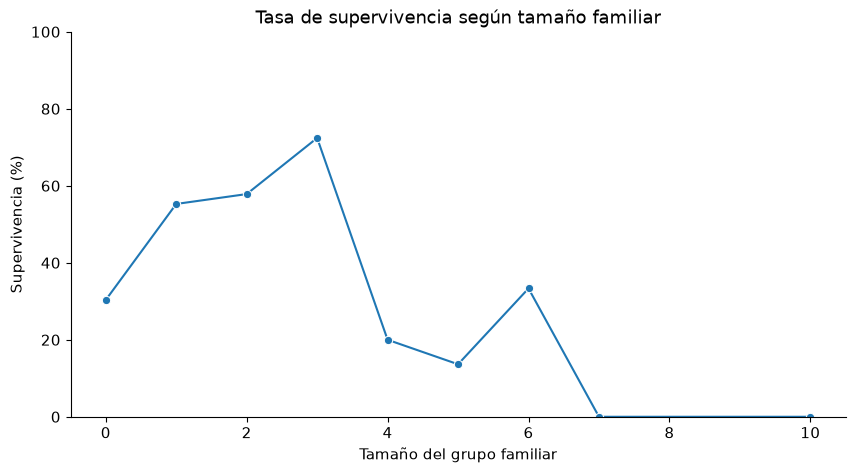

In [47]:
# Análisis del patrón de supervivencia según tamaño familiar

familia_patron = (
    df.groupby('family_size')['survived']
      .agg(['count', 'mean'])
      .reset_index()
)

familia_patron['tasa_supervivencia'] = familia_patron['mean'] * 100

print("Tasa de supervivencia según tamaño familiar:")
display(
    familia_patron[
        ['family_size', 'count', 'tasa_supervivencia']
    ].round(2)
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=familia_patron,
    x='family_size',
    y='tasa_supervivencia',
    marker='o'
)

plt.title('Tasa de supervivencia según tamaño familiar')
plt.xlabel('Tamaño del grupo familiar')
plt.ylabel('Supervivencia (%)')
plt.ylim(0, 100)

plt.show()

### Control por sexo: viajar solo vs. con familia
¿El efecto de viajar solo se explica por la composición?

In [48]:
# viaja_solo fue creada en la Sección VI
print(
    df.groupby(['sex', 'viaja_solo'])['survived']
      .agg(n='count', tasa=lambda s: s.mean() * 100)
      .round(1)
)

print('\n% de hombres según tipo de viaje:')
print(pd.crosstab(df['viaja_solo'], df['sex'], normalize='index').mul(100).round(1))

                      n  tasa
sex    viaja_solo            
female Con familia  188  71.3
       Solo         126  78.6
male   Con familia  166  27.1
       Solo         411  15.6

% de hombres según tipo de viaje:
sex          female  male
viaja_solo               
Con familia    53.1  46.9
Solo           23.5  76.5


#### Interpretación

La tasa de supervivencia no presenta un comportamiento lineal respecto al tamaño del grupo familiar. Se observa un aumento de la supervivencia desde los pasajeros que viajaban solos (`family_size = 0`, 30,35%) hasta los grupos de tamaño 3, que alcanzan una tasa de **72,41%**.

A partir de `family_size = 4`, la tasa disminuye considerablemente: alcanza **20,00%** para grupos de tamaño 4 y **13,64%** para grupos de tamaño 5. En los grupos más numerosos, la supervivencia también es baja, llegando a **0%** para tamaños 7 y 10. Los tamaños familiares más altos tienen pocos registros, por lo que sus porcentajes deben interpretarse con cautela.

Al controlar por sexo, se observa que el **77%** de los pasajeros que viajaban solos eran hombres, frente al **47%** entre quienes viajaban acompañados, por lo que parte de la menor supervivencia de los solos se explica por la composición por sexo. Dentro de cada sexo, los hombres solos sobreviven menos que los acompañados (**15,6%** vs **27,1%**), mientras que en las mujeres ocurre lo contrario (**78,6%** vs **71,3%**).



### 5. Tabla resumen de patrones, anomalías y hallazgos

| Hallazgo | Tipo | Interpretación |
|---|---|---|
| Diferencias de supervivencia según sexo | Patrón | Las mujeres sobreviven en mucha mayor proporción (74,2%) que los hombres (18,9%). |
| Diferencias de supervivencia según clase | Patrón | La supervivencia disminuye con la clase:<br>63,0% en Primera, 47,3% en Segunda y 24,2% en Tercera. |
| Valores extremos en `fare` | Anomalía | El criterio IQR identifica 116 valores atípicos, 104 de ellos de Primera Clase.<br>No son errores de registro y no se eliminan, porque representan diferencias reales de tarifa. |
| Registros con `fare = 0` | Anomalía | 15 registros, todos hombres que viajaban solos y embarcaron en Southampton; 14 no sobrevivieron.<br>Pueden corresponder a tripulación o a un error histórico de registro.<br>Se mantienen y se documentan con `fare_cero_flag`. |
| Pasajeros de edad avanzada | Anomalía | 26 pasajeros con 60 años o más y 8 con más de 65; 7 de esos 8 no sobrevivieron.<br>Son valores poco frecuentes pero reales, por lo que se mantienen. |
| Relación entre `family_size` y supervivencia | Patrón | La supervivencia aumenta hasta grupos de tamaño 3 y luego disminuye, con tasas muy bajas en grupos numerosos.<br>Parte de la menor supervivencia de quienes viajan solos se explica por la composición por sexo. |

<a id='X'></a>
## X. Supuestos, Limitaciones y Estado final del dataset

La presente sección define los supuestos que sostienen nuestro análisis, las limitaciones del trabajo realizado y el estado final del dataset que se obtiene para trabajar en la siguiente fase.

### 1. Supuestos
* Las 891 observaciones del dataset `titanic` de `seaborn` corresponden a un subconjunto de las cerca de 2.200 personas a bordo. Se asume que permiten **aproximar** los patrones de supervivencia del total de pasajeros, pero las tasas calculadas deben interpretarse como descriptivas de esta muestra y no como valores poblacionales exactos (ver limitaciones).
* Para `age` se asumió que los 177 valores faltantes (19,9%) pueden reemplazarse por la mediana del grupo correspondiente a su clase (`pclass`) y sexo (`sex`). La Sección IV mostró que la proporción de faltantes depende de variables observadas (27,7% en Tercera Clase frente a 6,0% en Segunda), por lo que los faltantes no son completamente aleatorios (MCAR). Se asume el mecanismo **MAR (Missing At Random)**: la ausencia depende de variables observadas y no de la edad en sí misma. Como la edad varía sistemáticamente por clase y sexo, imputar con la mediana global distorsionaría la distribución dentro de los subgrupos.
* Se asume que imputar los dos valores faltantes de `embarked` con la moda (Southampton) no altera los resultados debido a su baja incidencia (2 nulos, 0,22%).
* Se asume que los 15 registros con `fare = 0` son casos especiales (posible tripulación, pasajes de cortesía o errores de registro histórico) y no errores aleatorios; por ello se conservan y se marcan con la variable `fare_cero_flag`.
* Se asume que los 116 valores atípicos de `fare` detectados con el criterio IQR reflejan diferencias reales de tarifa (104 de ellos en Primera Clase) y no errores de registro, por lo que se conservan.
* Se asume que las 107 filas duplicadas exactas pueden corresponder a pasajeros distintos con atributos idénticos, por lo que se conservan.


### 2. Limitaciones
* No fue posible analizar la variable `deck` porque el 77,2% de sus valores está vacío e imputarlos generaría información artificial. Se excluye del análisis, perdiendo una variable que pudo aportar valor al señalar la ubicación del pasajero dentro del barco.
* El análisis realizado es descriptivo: no se aplicaron pruebas de hipótesis, por lo que las diferencias observadas entre grupos no tienen validación estadística y las asociaciones encontradas no implican causalidad.
* La muestra no es aleatoria, ya que se trata de un subconjunto histórico previamente definido, lo que limita la generalización de los resultados.
* La imputación concentra artificialmente las edades en los valores de las medianas; además, las categorías con pocos casos (`family_size` ≥ 4 o mayores de 61 años) entregan tasas poco estables.
* El dataset no incluye identificadores únicos por pasajero (nombre, número de ticket), lo que impide distinguir con certeza si las 107 filas duplicadas exactas son registros repetidos por error o pasajeros distintos con los mismos atributos.


### 3. Estado final del Dataset
Luego del proceso de limpieza, integración y transformación, el dataset conserva las 891 observaciones de origen. El único faltante que permanece en el dataset corresponde a deck, que es la variable a excluir del análisis por la decisión que se documentó en la Sección V. Por ello, se construye df_final, que omite 'deck' y pasa a ser la base limpia que se entrega a la fase de modelado. En la siguiente celda de código se muestran sus dimensiones y confirma la ausencia de valores nulos.

In [49]:
# Estado final del dataset
print(f'Dataset de trabajo (df): {df.shape}  ->  nulos en deck: {df["deck"].isnull().sum()}')

# Dataset analítico final: se excluye deck (77,2% de nulos, decisión de la Sección V)
df_final = df.drop(columns=['deck'])

print(f'\nDimensiones de df_final: {df_final.shape}')
print('\nValores nulos por variable en df_final:')
print(df_final.isnull().sum())
print(f'\nTotal de valores nulos en df_final: {df_final.isnull().sum().sum()}')

Dataset de trabajo (df): (891, 19)  ->  nulos en deck: 688

Dimensiones de df_final: (891, 18)

Valores nulos por variable en df_final:
survived          0
pclass            0
sex               0
age               0
sibsp             0
parch             0
fare              0
embarked          0
fare_cero_flag    0
puerto            0
pais              0
lat               0
lon               0
family_size       0
age_group         0
fare_bin          0
survived_label    0
viaja_solo        0
dtype: int64

Total de valores nulos en df_final: 0


**Obs:** `df_final` contiene 891 filas y 18 columnas, sin valores nulos en ninguna de las variables. Además de las variables originales depuradas, incluye los metadatos de puertos integrados (`puerto`, `pais`, `lat`, `lon`), la marca `fare_cero_flag` y las variables derivadas (`family_size`, `age_group`, `fare_bin`, `survived_label` y `viaja_solo`).

<a id='XI'></a>
## XI. Cierre del avance

### 1. Síntesis del trabajo realizado
* **Diagnóstico de calidad:** se identificaron valores faltantes (`deck` = 77,2%, `age` = 19,9%, `embarked` = 0,2%), con faltantes de `age` concentrados en Tercera Clase (no MCAR); 15 registros con `fare` = 0; 107 filas duplicadas exactas sin identificadores que permitan confirmarlas como errores; y 6 columnas redundantes derivadas de otras variables.
* **Limpieza e integración:** se eliminaron las columnas redundantes; se imputó `age` con la mediana estratificada por `pclass` × `sex` (validando su efecto sobre la distribución) y `embarked` con la moda; se conservaron y documentaron los duplicados; se marcaron los registros con `fare` = 0 mediante `fare_cero_flag`; y se integró una tabla auxiliar de puertos (país y coordenadas), cargada como fuente web desde el repositorio del proyecto, mediante un *merge* muchos-a-uno validado, sin alterar el número de filas ni introducir nulos.
* **Transformaciones:** se crearon cinco variables derivadas (`family_size`, `age_group`, `fare_bin`, `survived_label` y `viaja_solo`) para simplificar la exploración y agrupar variables continuas, verificando que no introducen valores faltantes.
* **Análisis exploratorio (EDA):** se realizó el análisis univariado de ocho variables con medidas descriptivas básicas y robustas, y el análisis bivariado de la supervivencia frente a sus principales predictores, incluyendo la interacción sexo × clase y la matriz de correlación. Además, se caracterizaron los valores atípicos y las anomalías.


### 2. Principales hallazgos
* El sexo es el factor más asociado a la supervivencia: sobrevivió el 74,2% de las mujeres frente al 18,9% de los hombres.
* La supervivencia presenta un gradiente socioeconómico: baja de 63,0% en Primera Clase a 24,2% en Tercera, y sube de 19,7% en el tramo de tarifa más bajo (Q1) a 58,1% en el más alto (Q4). `pclass` y `fare` son las variables numéricas con mayor correlación con `survived` (−0,34 y 0,26).
* Sexo y clase interactúan: las mujeres de Primera y Segunda Clase superan el 90% de supervivencia, pero en Tercera Clase bajan a 50%. En los hombres, ninguna clase supera el 37%.
* La edad influye en los extremos, no en el centro de la distribución: la mediana es similar entre sobrevivientes y no sobrevivientes (27 y 25 años), pero los niños de 0 a 5 años alcanzan un 70,5% de supervivencia, mientras que los mayores de 61 años solo un 22,7%.
* El tamaño familiar tiene una relación no lineal: la supervivencia sube desde 30,4% en quienes viajan solos hasta 72,4% en grupos familiares de tamaño 3, y cae a 20% en grupos de tamaño 4. La baja tasa de quienes viajan solos se explica en parte por su composición: el 76,5% de ellos son hombres, frente al 46,9% entre quienes viajan con familia.


### 3. Proyección a la siguiente fase
* **Modelado:** el problema a resolver es una clasificación binaria sobre `survived`. Se propone comenzar con una regresión logística como modelo base y luego compararla con modelos basados en árboles (árbol de decisión o Random Forest), capaces de capturar relaciones no lineales como la observada en `family_size` y la interacción sexo × clase. Previo al modelamiento, se validarán los hallazgos con pruebas de hipótesis (por ejemplo, chi-cuadrado para asociaciones entre categóricas). Para evitar fuga de información (*data leakage*), las medianas de imputación se calcularán solo con los datos de entrenamiento.
* **Desbalance de clases:** la variable objetivo presenta un desbalance moderado (61,6% no sobrevivió y 38,4% sobrevivió). Un modelo que siempre prediga "No sobrevivió" obtendría una exactitud (*accuracy*) de 61,6%, que será la línea base. Se utilizará una partición entrenamiento/prueba estratificada, validación cruzada estratificada y métricas complementarias a la exactitud (precisión, *recall*, F1 y ROC-AUC); de ser necesario, se evaluará el ajuste `class_weight='balanced'`.
* **Variables candidatas:** `sex`, `pclass`, `age`, `fare_bin`, `family_size`, `embarked` y `fare_cero_flag`, además de la interacción `sex` × `pclass`. Se excluyen `deck`, `survived_label`, `puerto`, `pais`, `lat` y `lon`. Tampoco se utilizarán conjuntamente `family_size`, `sibsp` y `parch`, para evitar multicolinealidad. Las variables categóricas se codificarán mediante *one-hot encoding*.


---
<a id='XII'></a>
## XII. Bibliografía

[1] Paraíso, S. (2026). *Material del curso MCDI503 — Exploración Inteligente para la Ciencia de Datos*. Universidad Andrés Bello, Online.

[2] Waskom, M. (2021). Seaborn: statistical data visualization. *Journal of Open Source Software*, *6*(60), 3021. https://doi.org/10.21105/joss.03021

[3] McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

[4] Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

[5] VanderPlas, J. (2016). *Python Data Science Handbook*. O’Reilly Media. https://jakevdp.github.io/PythonDataScienceHandbook/

[6] Wickham, H. (2014). Tidy data. *Journal of Statistical Software*, *59*(10), 1–23. https://doi.org/10.18637/jss.v059.i10

[7] Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
